# Chapitre 4 — EDA diagnostique et qualité des données

**Durée estimée : 8-10 heures**

---

## Objectifs d'apprentissage

À la fin de ce chapitre, vous serez capable de :

1. **Distinguer** l'EDA diagnostique (trouver les problèmes) de l'EDA analytique (comprendre les patterns)
2. **Évaluer** la qualité des données selon les 6 dimensions standardisées
3. **Détecter** les valeurs manquantes, doublons et outliers avec les outils pandas appropriés
4. **Documenter** les problèmes identifiés dans une checklist de qualité priorisée

---

## 4.6 Détection des outliers

### Qu'est-ce qu'un outlier ?

Un **outlier** (valeur aberrante) est une observation qui s'écarte significativement des autres.

**Attention :** Un outlier n'est pas toujours une erreur !
- ❌ Erreur : Âge de 200 ans (impossible)
- ✅ Valeur extrême légitime : Salaire de 500k€ (rare mais réel)

### Méthode 1 : IQR (Interquartile Range)

L’objectif est de détecter les valeurs atypiques dans un jeu de données à l’aide de la méthode IQR (Interquartile Range) pour :

	•	Comprendre la distribution des données
	•	Identifier les valeurs extrêmes qui peuvent fausser l’analyse
	•	Décider si elles doivent être conservées, corrigées ou supprimées

**1️⃣ Jeu de données**

In [32]:
import numpy as np
import pandas as pd

# Création du jeu de données
np.random.seed(42)
salaires = np.concatenate([
    np.random.normal(50000, 10000, 100),  # Salaires normaux
    np.array([150000, 200000, 5000])      # Outliers
])
df_outliers = pd.DataFrame({'salaire': salaires})

df_outliers.head()
# 100 salaires simulés autour de 50 000 €
# 3 outliers extrêmes : 5 000 €, 150 000 €, 200 000 €

,salaire
0,54967.141530
1,48617.356988
2,56476.885381
3,65230.298564
4,47658.466253


**2️⃣ Rappel : Quartiles et IQR**

**a) Quartiles**

Principe général

	•	Q1 (1er quartile) : valeur en dessous de laquelle se trouvent 25 % des données
	•	Q2 (2e quartile) : médiane, 50 % des données en dessous et 50 % au-dessus
	•	Q3 (3e quartile) : valeur en dessous de laquelle se trouvent 75 % des données

👉 Les quartiles sont donc des positions, pas des mesures de dispersion.


``` markdown
0%        25%        50%        75%        100%
|----------|----------|----------|-----------|
     Q1         Q2         Q3

	•	Le dataset est trié
	•	Chaque segment contient 25 % des observations
	•	Les quartiles sont les frontières entre ces segments
```

Exemple simple

Dataset trié :

[5, 20, 50, 80, 120]

	•	Q2 (médiane) = 50
	•	Q1 = médiane des valeurs en dessous de Q2 → [5, 20] → 12.5
	•	Q3 = médiane des valeurs au-dessus de Q2 → [80, 120] → 100

⸻


In [ ]:
# 1er quartile (Q1)
Q1 = df_outliers['salaire'].quantile(0.25)

# 3e quartile (Q3)
Q3 = df_outliers['salaire'].quantile(0.75)


**b) IQR : la dispersion interquartile**

L’IQR (InterQuartile Range) mesure la dispersion des 50 % centraux des données.

IQR = Q3 - Q1

👉 L’IQR est une distance, pas une position.

Ce que mesure l’IQR
	•	À quel point les valeurs « centrales » sont étalées
	•	Il ignore les valeurs extrêmes
	•	Il est donc robuste aux outliers

La médiane (Q2) n’est pas utilisée pour le calcul de l’IQR, mais elle peut être visualisée pour référence sur un boxplot.

👉 Deux datasets peuvent avoir la même médiane (Q2) mais une dispersion très différente.



Schéma visuel de l’IQR

|----------[========== IQR ==========]----------|
           Q1          Q2          Q3

	•	La zone entre Q1 et Q3 représente les 50 % centraux
	•	La largeur de cette zone = dispersion interquartile



Exemple de calcul de l’IQR 

Dataset trié :

[5, 20, 50, 80, 120]

	•	Q1 = 12.5
	•	Q3 = 100

IQR = Q3 - Q1 = 100 - 12.5 = 87.5

👉 Dispersion forte : les valeurs centrales sont très éloignées.

In [ ]:
# IQR
IQR = Q3 - Q1

print(f"Q1 = {Q1:.0f}, Q3 = {Q3:.0f}, IQR = {IQR:.0f}")

Q1 = 43988, Q3 = 55050, IQR = 11062


**3️⃣ Bornes pour détecter les outliers**

Pourquoi l’IQR est très utilisé

L’IQR sert notamment à détecter les valeurs aberrantes (outliers) :

👉 Méthode robuste, très utilisée en data analysis et en qualité des données.

Pourquoi 1.5 ?

	•	Conventions statistiques (John Tukey)
	•	Équilibre entre détecter les vrais outliers et ne pas exclure les valeurs normales

In [ ]:
# Borne inférieure → valeurs trop petites :
borne_inf = Q1 - 1.5 * IQR

# Borne supérieure → valeurs trop grandes :
borne_sup = Q3 + 1.5 * IQR

Bornes : [27396, 71642]


**Points clés à retenir**

	•	Q1, Q2, Q3 = positions dans le dataset
	•	Q2 = médiane (centre)
	•	IQR = mesure de dispersion
	•	IQR ≠ taille du dataset
	•	IQR ≠ nombre de valeurs entre Q1 et Q3
	•	IQR = Q3 − Q1

**5️⃣ Détection des outliers**

In [35]:
# Étape 1 : valeurs trop petites
outliers_inf = df_outliers[df_outliers['salaire'] < borne_inf]

# Étape 2 : valeurs trop grandes
outliers_sup = df_outliers[df_outliers['salaire'] > borne_sup]

# Étape 3 : combiner les deux
outliers = pd.concat([outliers_inf, outliers_sup])

print(f"Bornes : [{borne_inf:.0f}, {borne_sup:.0f}]")
print(f"Outliers détectés : {len(outliers)} ({len(outliers)/len(df_outliers)*100:.1f}%)")
print("Valeurs :")
print(outliers['salaire'].values)

Bornes : [27396, 71642]
Outliers détectés : 4 (3.9%)
Valeurs :
[ 23802.5489591   5000.        150000.        200000.       ]


Les valeurs en dehors de [borne_inf, borne_sup] → outliers

1️⃣ Q1 = 43988

.	C’est le 1er quartile : 25 % des salaires sont ≤ 43 988 €

•	Si on utilisait juste Q1 comme seuil, seules les valeurs en dessous de 43 988 € seraient considérées “petites”

•	Mais certaines valeurs juste en dessous de Q1 sont tout à fait normales, donc ce serait trop strict

2️⃣ Étendre la borne avec 1.5*IQR

•	IQR = Q3 − Q1 → mesure de la dispersion centrale

•	Multiplier par 1.5 et soustraire à Q1 :

borne_inf = Q1 - 1.5 * IQR = 27 396
•	Pourquoi ?

•	On élargit la zone acceptable à gauche

•	Les salaires légèrement inférieurs à Q1 ne sont pas éliminés

•	Seules les valeurs beaucoup plus éloignées du centre (ex. 5 000 €) sont considérées outliers


3️⃣ Visualisation conceptuelle

borne_inf = 27396  ← valeurs < 27396 → outliers (très faibles)

Q1        = 43988  ← début de la moitié basse des données (zone normale)

Q3        = ...    ← fin de la moitié haute des données

borne_sup = ...    ← valeurs > borne_sup → outliers très élevés

•	Donc, la méthode protège les valeurs normales proches du Q1

•	Les seules valeurs éliminées sont celles vraiment atypiques, comme 5 000 €


💡 En résumé :
	•	Q1 donne la limite “classique” de 25 % des plus petites valeurs
	•	En faisant Q1 − 1.5*IQR, on étend la tolérance pour inclure toutes les valeurs normales, et ne disqualifie que les véritables outliers.

**6️⃣ Décision métier**

	•	Outliers ≠ erreurs → vérifier la cohérence métier avant suppression
	•	Options :
	    1.	Corriger si erreur de saisie
	    2.	Supprimer si impact sur les analyses
	    3.	Conserver si pertinents (ex. très hauts revenus réels)

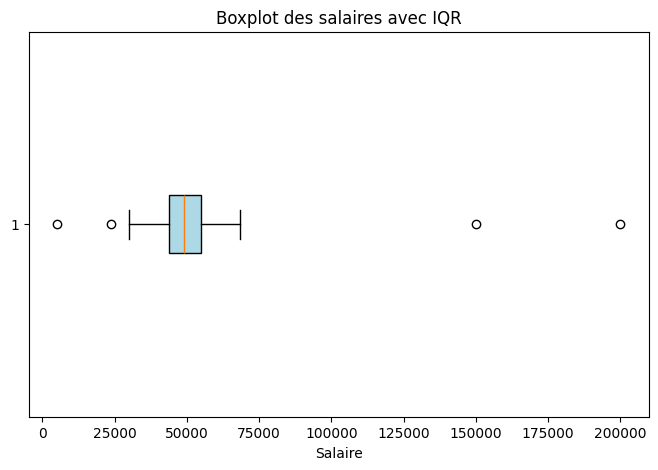

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.boxplot(df_outliers['salaire'], vert=False, patch_artist=True,
            boxprops=dict(facecolor='lightblue'))
plt.title("Boxplot des salaires avec IQR")
plt.xlabel("Salaire")
plt.show()

### Méthode 2 : Z-Score

**1️⃣ Concept du Z-score**

Le **Z-score** mesure **à combien d’écarts-types une valeur est du centre de la distribution** :  

$$
Z = \frac{x - \mu}{\sigma}
$$

où :  
- `x` = valeur à analyser  
- `μ` = moyenne de la série  
- `σ` = écart-type de la série  

***Interprétation*** :  
- |Z| = 0 → valeur exactement à la moyenne  
- |Z| = 1 → à 1 écart-type de la moyenne  
- |Z| = 3 → à 3 écarts-types → **très éloignée**, candidate outlier  


**2️⃣ Détection avec seuil**

- Convention : **|Z| > 3** → outlier potentiel  
- Pourquoi ?  
  - Dans une distribution normale, 99,7 % des valeurs sont **dans ±3 écarts-types**  
  - Les valeurs au-delà → extrêmement rares → suspectées outliers  

**3️⃣ Implémentation en Python**

In [ ]:
from scipy import stats

def detecter_outliers_zscore(series, seuil=3):
    """Détecte les outliers avec le Z-score."""
    # Calcul du Z-score pour chaque valeur (en ignorant les NaN)
    z_scores = stats.zscore(series.dropna())
    
    # Masque des valeurs dont le |Z| dépasse le seuil
    outliers_mask = abs(z_scores) > seuil
    #abs signifie valeur absolue
    
    # Retourner uniquement les outliers
    return series.dropna()[outliers_mask]

**4️⃣ Application sur notre jeu de données**

In [39]:
outliers_z = detecter_outliers_zscore(df_outliers['salaire'])

print(f"Outliers (|Z| > 3) : {len(outliers_z)}")
print(f"Valeurs : {outliers_z.values}")

Outliers (|Z| > 3) : 2
Valeurs : [150000. 200000.]


### Comparaison des méthodes

1️⃣ Pourquoi le Z-score est recommandé pour les distributions normales

- Le **Z-score** repose sur la moyenne (μ) et l’écart-type (σ) :

$$
Z = \frac{x - \mu}{\sigma}
$$

- Hypothèse implicite : les données suivent une **distribution normale (ou proche)**  
- Dans une distribution normale :  
  - La majorité des valeurs se concentrent autour de la moyenne  
  - ±1σ → 68 % des valeurs, ±2σ → 95 %, ±3σ → 99,7 %  
- Donc, quand on dit |Z| > 3, on détecte des valeurs **extrêmement rares et éloignées de la moyenne**  
- Avantage : Z-score **quantifie exactement combien d’écarts-types une valeur est du centre**, ce qui est très précis pour les normales  

💡 Exemple : les salaires d’une grande entreprise souvent centrés autour d’une moyenne (loi normale approximative)

---

2️⃣ Pourquoi l’IQR est plus robuste pour les distributions asymétriques ou bruitées

- L’**IQR** est basé sur Q1 et Q3, donc sur la **plage centrale des 50 % des données**  
- Il **ignore les valeurs extrêmes** lors du calcul de la dispersion  
- Dans des distributions asymétriques (ex. salaires très dispersés) :  
  - La moyenne et l’écart-type peuvent être **tirés par les extrêmes**  
  - Z-score risque de **mal détecter les outliers** : certaines valeurs “normales” peuvent apparaître comme extrêmes, ou certaines valeurs extrêmes passent inaperçues  
- L’IQR reste **stable** et détecte correctement les valeurs vraiment éloignées de la majorité  

💡 Exemple : revenus d’une population avec beaucoup de faibles revenus et quelques très hauts revenus  
- La distribution est très asymétrique  
- Le Z-score donnerait des faux positifs ou faux négatifs  
- L’IQR détecte les vrais outliers au-dessus ou en dessous de la zone centrale  

---

🔹 Résumé

| Méthode  | Quand l’utiliser                         | Pourquoi                                                     |
|----------|----------------------------------------|-------------------------------------------------------------|
| **Z-score**  | Distribution normale                     | Basé sur moyenne et écart-type, précis pour données symétriques |
| **IQR**      | Distribution asymétrique ou bruitée     | Robuste aux valeurs extrêmes, ne se laisse pas influencer par la forme de la distribution |

***Exemple où IQR fonctionne mais pas Z-score***

Contexte

	•	Distribution très asymétrique, par exemple des salaires :
	•	90 % des salariés : 30 000 – 50 000 €
	•	Quelques hauts revenus : 150 000 – 200 000 €
	•	Moyenne et écart-type sont tirés par les hauts revenus → Z-score devient trompeur

Pourquoi ?

•	La moyenne est tirée vers les hauts salaires, donc ±3σ inclut même les valeurs très extrêmes.

•	IQR ignore les extrêmes et détecte les vrais outliers.

1️⃣ IQR et le nombre d’outliers

    •	L’IQR utilise Q1 et Q3, donc la plage centrale des 50 % des valeurs.
    •	Si très peu d’outliers :
    •	Q1 et Q3 vont être proches de la majorité des valeurs, car les extrêmes ne changent pas la médiane et les quartiles.
    •	La borne IQR (Q1 − 1.5IQR, Q3 + 1.5IQR) peut alors englober l’outlier isolé, car la plage centrale est large.
    •	Donc avec peu d’outliers, l’IQR peut rater des valeurs réellement extrêmes.

***Exemple où Z-score fonctionne mais pas IQR***

Contexte
	•	Distribution presque normale, petite taille, peu d’outliers
	•	Exemple : petites mesures physiques, échantillon homogène

Pourquoi ?

•	IQR dépend de la dispersion centrale (50 % des valeurs) → avec un seul outlier, la plage centrale est large → il ne détecte rien

•	Z-score prend en compte la distance à la moyenne, détecte même un outlier isolé

Z-score et l’écart-type

	•	Z-score utilise la moyenne et l’écart-type (σ) de toutes les valeurs, pas seulement du centre.
	•	Même un seul outlier très éloigné va :
	•	Être à plusieurs écarts-types de la moyenne → |Z| > 3 → détecté.
	•	Donc Z-score ne dépend pas du nombre d’outliers pour les détecter.
	•	Limite : si la distribution est très asymétrique, la moyenne et σ peuvent être tirées par d’autres extrêmes, ce qui peut masquer certains outliers.

### ✍️ Exercice 4.6 : Détection d'outliers (15 min)

In [1]:
import pandas as pd
import numpy as np
from scipy import stats

# Données de salaires avec outliers
np.random.seed(42)
salaires = np.concatenate([
    np.random.normal(50000, 10000, 950),  # Salaires normaux
    np.array([150000, 200000, -5000, 300000, 250000])  # Outliers
])
df_ex = pd.DataFrame({'salaire': salaires})

print(f"Statistiques descriptives :")
print(df_ex['salaire'].describe())

Statistiques descriptives :
count       955.000000
mean      50875.181745
std       15472.633879
min       -5000.000000
25%       43541.536806
50%       50283.183761
75%       56528.784538
max      300000.000000
Name: salaire, dtype: float64


In [2]:
# 1. Méthode IQR
Q1 = df_ex['salaire'].quantile(0.25)
Q3 = df_ex['salaire'].quantile(0.75)
IQR = Q3 - Q1
borne_inf = Q1 - 1.5 * IQR
borne_sup = Q3 + 1.5 * IQR

outliers_iqr = df_ex[(df_ex['salaire'] < borne_inf) | (df_ex['salaire'] > borne_sup)]
print(f"Méthode IQR :")
print(f"  Bornes : [{borne_inf:.0f}, {borne_sup:.0f}]")
print(f"  Outliers : {len(outliers_iqr)}")

Méthode IQR :
  Bornes : [24061, 76010]
  Outliers : 13


In [3]:
print(outliers_iqr)

           salaire
74    23802.548959
179   77201.691666
209   88527.314907
262   17587.326599
478   80788.808085
646   23031.133571
668   23490.301916
755   76323.820648
950  150000.000000
951  200000.000000
952   -5000.000000
953  300000.000000
954  250000.000000


In [4]:
# 2. Méthode Z-Score
z_scores = stats.zscore(df_ex['salaire'])
outliers_zscore = df_ex[abs(z_scores) > 3]
print(f"\nMéthode Z-Score :")
print(f"  Outliers (|Z| > 3) : {len(outliers_zscore)}")


Méthode Z-Score :
  Outliers (|Z| > 3) : 5


In [5]:
print(outliers_zscore)

      salaire
950  150000.0
951  200000.0
952   -5000.0
953  300000.0
954  250000.0


In [ ]:
# Questions :
print("\n--- Réponses aux questions ---")

# a) Pourquoi les deux méthodes donnent-elles des résultats différents ?
print("\na) Différence entre méthodes :")
print("   - IQR est basé sur les quartiles (robuste aux outliers)")
print("   - Z-Score est basé sur moyenne/écart-type (sensible aux outliers)")
print("   - Les outliers extrêmes gonflent l'écart-type, rendant Z-Score moins sensible")

# b) Le salaire de -5000 est-il une erreur ou une valeur légitime ?
print("\nb) Salaire de -5000 :")
print("   → C'est une ERREUR car un salaire ne peut pas être négatif")
print("   → Ce type d'outlier est une erreur de saisie ou de conversion")

# c) Quelle méthode préférez-vous ici et pourquoi ?
print("\nc) Méthode préférée :")
print("   → IQR est préférable car :")
print("   - Plus robuste face aux valeurs extrêmes")
print("   - Détecte mieux les outliers quand la distribution est perturbée")